<a href="https://colab.research.google.com/github/giusedmb/Embedded-System---Number-Recogniser-with-Lattice-Board/blob/main/reduction_%26_inversion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Carica un'immagine dal tuo PC:


Saving Opera_senza_titolo 2.png to Opera_senza_titolo 2.png


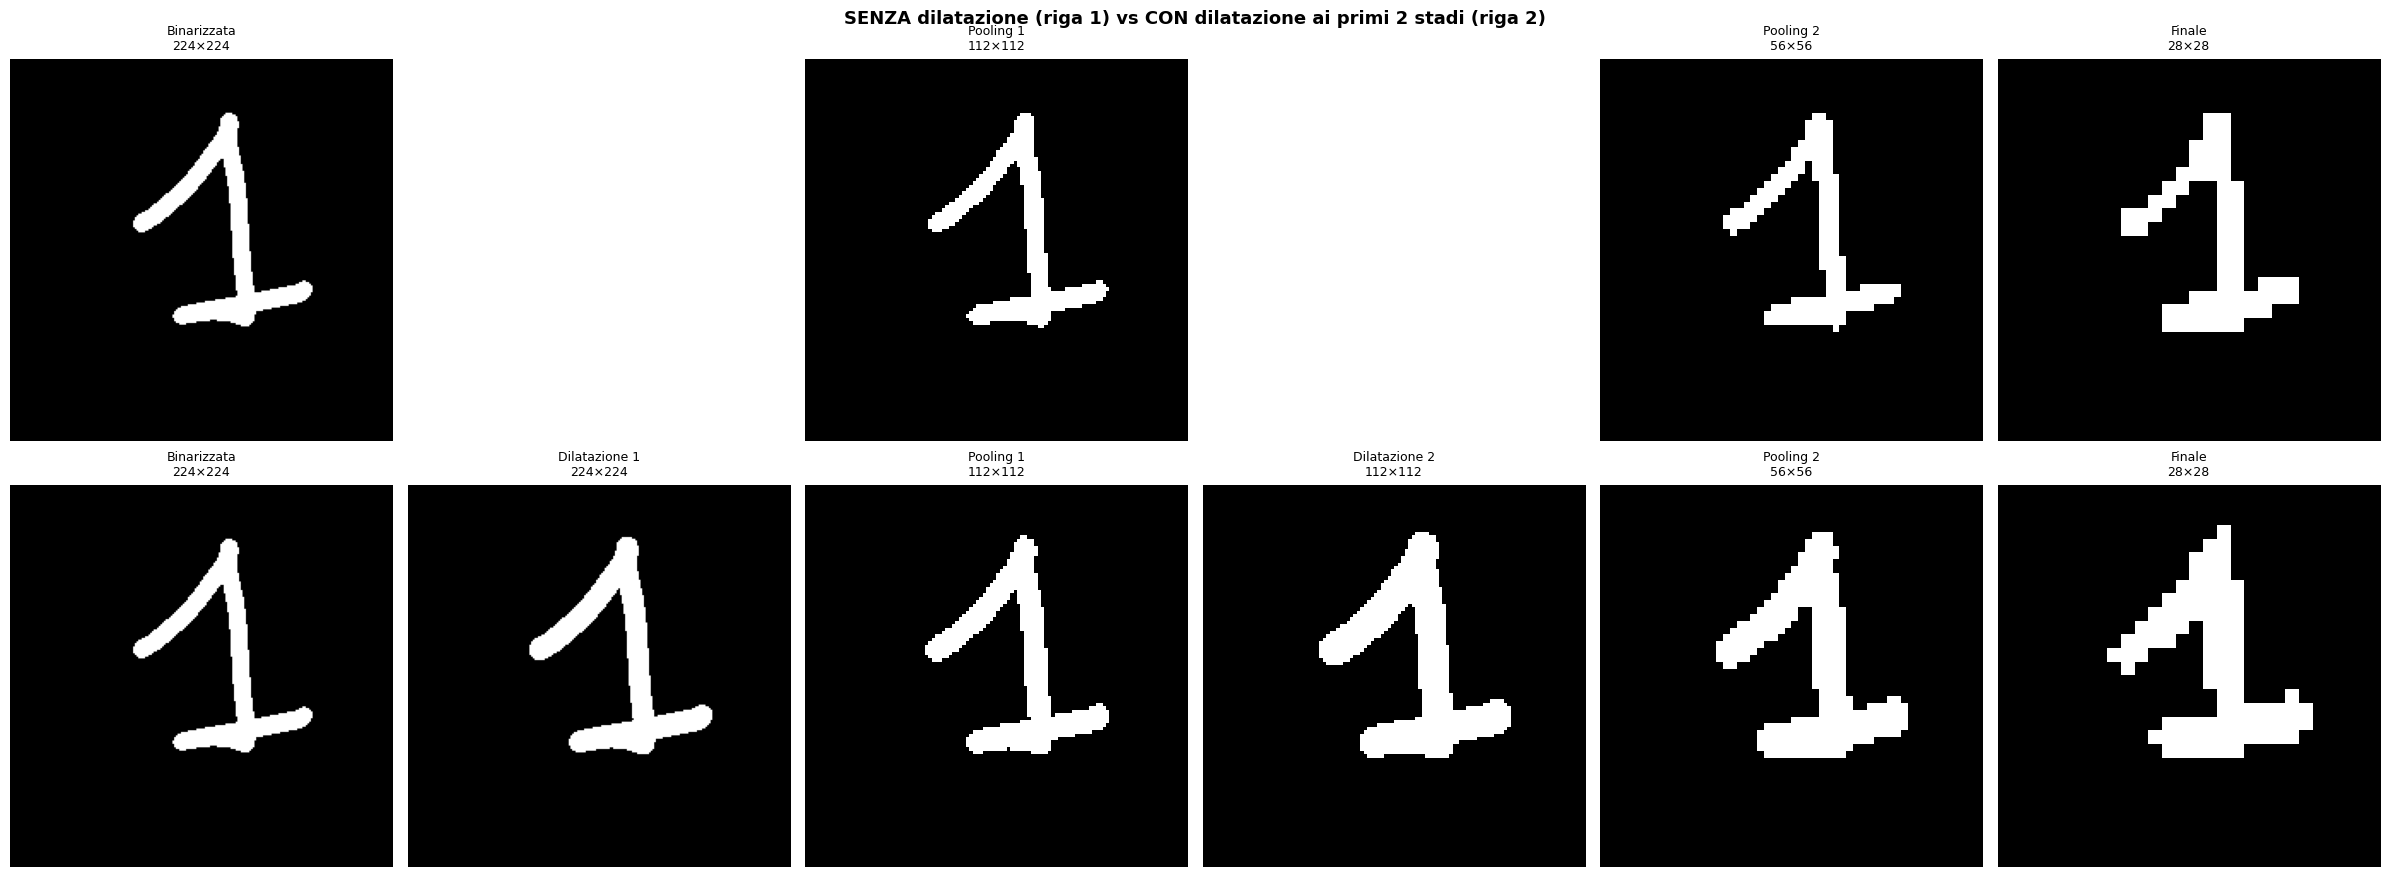

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== Riepilogo pipeline hardware ===
  [1] Binarizzazione (soglia G<100):        224×224 → binaria
  [2] Dilatazione 3×3 (OR 9px):             224×224 → linee rinforzate
  [3] Pooling 2×2 maggioranza:               224×224 → 112×112
  [4] Dilatazione 3×3 (OR 9px):             112×112 → linee rinforzate
  [5] Pooling 2×2 maggioranza:               112×112 →  56×56
  [6] Pooling 2×2 maggioranza (no dilat.):   56×56  →  28×28

  Pixel bianchi finale CON dilatazione:  92
  Pixel bianchi finale SENZA dilatazione: 64
  Pixel recuperati:                        28


In [ ]:
from google.colab import files
import cv2
import numpy as np
from matplotlib import pyplot as plt

# =====================================================================
# 1. Dilatazione Morfologica 3x3 (OR logico su finestra 3x3)
#    In hardware FPGA → line buffer + OR a 9 ingressi (costo minimo)
# =====================================================================
def dilate_3x3(image):
    """
    Simula il comportamento hardware di un modulo di dilatazione FPGA.
    Un pixel è 1 se ALMENO UN pixel nella sua finestra 3x3 è 1.

    Equivalente Verilog: sliding window 3x3 con line buffer,
    output = OR logico di tutti i 9 pixel della finestra.
    """
    result = np.zeros_like(image)
    for dy in range(-1, 2):
        for dx in range(-1, 2):
            shifted = np.roll(np.roll(image, dy, axis=0), dx, axis=1)
            result = np.logical_or(result, shifted)
    return result.astype(np.uint8)

# =====================================================================
# 2. Pooling 2x2 a Maggioranza (Voto >= 2 su 4)
#    In hardware FPGA → sommatore a 2 bit + comparatore
# =====================================================================
def pool_2x2_majority(image):
    """
    Simula il pooling hardware 2x2.
    Se >= 2 pixel su 4 sono '1', il blocco vale 1.

    Equivalente Verilog: accumulatore a 2 bit su 4 pixel, output = (sum >= 2).
    """
    block_sum = (image[0::2, 0::2] +
                 image[1::2, 0::2] +
                 image[0::2, 1::2] +
                 image[1::2, 1::2])
    return np.where(block_sum >= 2, 1, 0).astype(np.uint8)

# =====================================================================
# 3. Caricamento immagine
# =====================================================================
print("Carica un'immagine dal tuo PC:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img = cv2.imread(filename)
img_224 = cv2.resize(img, (224, 224))

# =====================================================================
# 4. Binarizzazione sul canale Verde
#    Verde < 100  → inchiostro scuro  → 1 (bianco per la rete neurale)
#    Verde >= 100 → foglio chiaro     → 0 (nero per la rete neurale)
# =====================================================================
G = img_224[:, :, 1]
T = 100
img_bin = np.where(G < T, 1, 0).astype(np.uint8)

# =====================================================================
# 5. Pipeline con dilatazione ai primi DUE stadi
#
#    Stadio 1: dilata @ 224px → pooling → 112px
#    Stadio 2: dilata @ 112px → pooling →  56px
#    Stadio 3:                  pooling →  28px  (niente dilatazione)
#
#    Ragionamento: al terzo stadio i tratti sono già abbastanza robusti
#    e un'ulteriore dilatazione a 56px rischierebbe di fondere parti
#    adiacenti della cifra (es. centro della '8', interno della '0').
# =====================================================================

# Stadio 1: dilata a 224px, poi pool → 112px
img_bin_d1 = dilate_3x3(img_bin)
img_112    = pool_2x2_majority(img_bin_d1)

# Stadio 2: dilata a 112px, poi pool → 56px
img_112_d2 = dilate_3x3(img_112)
img_56     = pool_2x2_majority(img_112_d2)

# Stadio 3: pool diretto → 28px (nessuna dilatazione)
img_28 = pool_2x2_majority(img_56)

# =====================================================================
# 6. Pipeline originale (senza dilatazione) per confronto visivo
# =====================================================================
img_112_old = pool_2x2_majority(img_bin)
img_56_old  = pool_2x2_majority(img_112_old)
img_28_old  = pool_2x2_majority(img_56_old)

# =====================================================================
# 7. Visualizzazione comparativa
# =====================================================================
fig, axes = plt.subplots(2, 6, figsize=(24, 9))
fig.suptitle("SENZA dilatazione (riga 1) vs CON dilatazione ai primi 2 stadi (riga 2)",
             fontsize=13, fontweight='bold')

# Titoli colonne
cols = ["Binarizzata\n224×224",
        "Dilatazione 1\n224×224",
        "Pooling 1\n112×112",
        "Dilatazione 2\n112×112",
        "Pooling 2\n56×56",
        "Finale\n28×28"]

# --- Riga 1: senza dilatazione ---
axes[0, 0].imshow(img_bin * 255, cmap='gray')
axes[0, 1].set_visible(False)
axes[0, 2].imshow(img_112_old * 255, cmap='gray')
axes[0, 3].set_visible(False)
axes[0, 4].imshow(img_56_old * 255, cmap='gray')
axes[0, 5].imshow(img_28_old * 255, cmap='gray')
axes[0, 5].set_title("⚠ Finale SENZA", fontsize=10)

# --- Riga 2: con dilatazione ai primi due stadi ---
axes[1, 0].imshow(img_bin * 255, cmap='gray')
axes[1, 1].imshow(img_bin_d1 * 255, cmap='gray')
axes[1, 2].imshow(img_112 * 255, cmap='gray')
axes[1, 3].imshow(img_112_d2 * 255, cmap='gray')
axes[1, 4].imshow(img_56 * 255, cmap='gray')
axes[1, 5].imshow(img_28 * 255, cmap='gray')
axes[1, 5].set_title("✓ Finale CON", fontsize=10)

# Titoli e formattazione
for col, title in enumerate(cols):
    axes[0, col].set_title(title, fontsize=9)
    axes[1, col].set_title(title, fontsize=9)
for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.show()

# =====================================================================
# 8. Salva e scarica
# =====================================================================
cv2.imwrite("output_28x28.png", img_28 * 255)
files.download("output_28x28.png")

print("\n=== Riepilogo pipeline hardware ===")
print(f"  [1] Binarizzazione (soglia G<{T}):        224×224 → binaria")
print(f"  [2] Dilatazione 3×3 (OR 9px):             224×224 → linee rinforzate")
print(f"  [3] Pooling 2×2 maggioranza:               224×224 → 112×112")
print(f"  [4] Dilatazione 3×3 (OR 9px):             112×112 → linee rinforzate")
print(f"  [5] Pooling 2×2 maggioranza:               112×112 →  56×56")
print(f"  [6] Pooling 2×2 maggioranza (no dilat.):   56×56  →  28×28")
print(f"\n  Pixel bianchi finale CON dilatazione:  {img_28.sum()}")
print(f"  Pixel bianchi finale SENZA dilatazione: {img_28_old.sum()}")
print(f"  Pixel recuperati:                        {img_28.sum() - img_28_old.sum()}")